In [44]:
import requests
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [45]:
cities = {
    "Mumbai":    {"lat" : 19.08, "lon": 72.88},
    "Delhi":     {"lat": 28.61, "lon": 77.21},
    "Bangalore": {"lat": 12.97, "lon": 77.59},
    "Chennai":   {"lat": 13.08, "lon": 80.27},
    "Kolkata":   {"lat": 22.57, "lon": 88.36},
    "Hyderabad": {"lat": 17.39, "lon": 78.49},
}

In [46]:
def fetch_weather(city, lat, lon):
    url = "https://api.open-meteo.com/v1/forecast"

    params = {
        "latitude": lat,
        "longitude": lon,
        "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max",
        "timezone": "Asia/Kolkata",
        "past_days": 30,    # last 30 days
        "forecast_days": 1
    }

    try:
        response = requests.get(url, params = params, timeout = 10)
        response.raise_for_status()

        data = response.json()
        daily = data["daily"]

        df = pd.DataFrame({

            "date": daily["time"],
            "temp_max": daily["temperature_2m_max"],
            "temp_min": daily["temperature_2m_min"],
            "precipitation": daily["precipitation_sum"],
            "windspeed": daily["windspeed_10m_max"],
            "city": city
        })

        return df

    except Exception as e:
        print(f"Error fetching {city}: {e}")
        return None

In [47]:
#Fetching All the Cities

all_data = []

for city, coordinates in cities.items():
    print(f"Fetching {city}...")

    df_city = fetch_weather(city, coordinates["lat"], coordinates["lon"])

    if df_city is not None:
        all_data.append(df_city)

Fetching Mumbai...
Fetching Delhi...
Fetching Bangalore...
Fetching Chennai...
Fetching Kolkata...
Fetching Hyderabad...


In [48]:
#Combining all cities into one DataFrame

df = pd.concat(all_data, ignore_index = True)
df["date"] = pd.to_datetime(df["date"])

print(f"\n Total Records: {len(df)} \n \n")
print(df.head())
print(df.info())


 Total Records: 186 
 

        date  temp_max  temp_min  precipitation  windspeed    city
0 2026-04-16      32.5      25.2            0.0       13.0  Mumbai
1 2026-04-17      32.5      24.8            0.0       15.5  Mumbai
2 2026-04-18      34.2      25.6            0.0       16.8  Mumbai
3 2026-04-19      34.2      27.2            0.0       18.4  Mumbai
4 2026-04-20      35.0      26.8            0.0       14.9  Mumbai
<class 'pandas.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           186 non-null    datetime64[us]
 1   temp_max       186 non-null    float64       
 2   temp_min       186 non-null    float64       
 3   precipitation  186 non-null    float64       
 4   windspeed      186 non-null    float64       
 5   city           186 non-null    str           
dtypes: datetime64[us](1), float64(4), str(1)
memory usage: 8.8 KB
None


In [49]:
df

,date,temp_max,temp_min,precipitation,windspeed,city
0,2026-04-16,32.5,25.2,0.0,13.0,Mumbai
1,2026-04-17,32.5,24.8,0.0,15.5,Mumbai
2,2026-04-18,34.2,25.6,0.0,16.8,Mumbai
3,2026-04-19,34.2,27.2,0.0,18.4,Mumbai
4,2026-04-20,35.0,26.8,0.0,14.9,Mumbai
...,...,...,...,...,...,...
181,2026-05-12,36.5,26.1,2.0,11.0,Hyderabad
182,2026-05-13,36.8,26.5,1.5,10.6,Hyderabad
183,2026-05-14,36.8,28.5,0.3,10.5,Hyderabad
184,2026-05-15,37.4,27.5,0.2,9.8,Hyderabad


In [50]:
#Cleaning the Data

print(f"Nulls: \n {df.isnull().sum()}")

df["temp_max"].fillna(df["temp_max"].mean())
df["temp_min"].fillna(df["temp_min"].mean())
df["precipitation"].fillna(0)
df["windspeed"].fillna(df["windspeed"].mean())

df["temp_range"] = df["temp_max"] - df["temp_min"]
df["month"] = df["date"].dt.month
df["week"] = df["date"].dt.isocalendar().week

# Summary per city
city_summary = df.groupby("city").agg({
    "temp_max": "mean",
    "temp_min": "mean",
    "precipitation": "sum",
    "windspeed": "mean"
}).round(2).reset_index()

print("\n City Summary:")
print(city_summary)

# Save cleaned data
df.to_csv("weather_data.csv", index=False)
city_summary.to_csv("city_summary.csv", index=False)
print("\n Data saved!")

Nulls: 
 date             0
temp_max         0
temp_min         0
precipitation    0
windspeed        0
city             0
dtype: int64

 City Summary:
        city  temp_max  temp_min  precipitation  windspeed
0  Bangalore     34.17     22.72           14.7      14.63
1    Chennai     34.73     27.84           32.1      18.15
2      Delhi     37.88     26.06           18.0      15.09
3  Hyderabad     37.61     26.92            5.1      11.63
4    Kolkata     34.11     25.41          147.1      14.81
5     Mumbai     34.15     27.50            0.0      16.32

 Data saved!


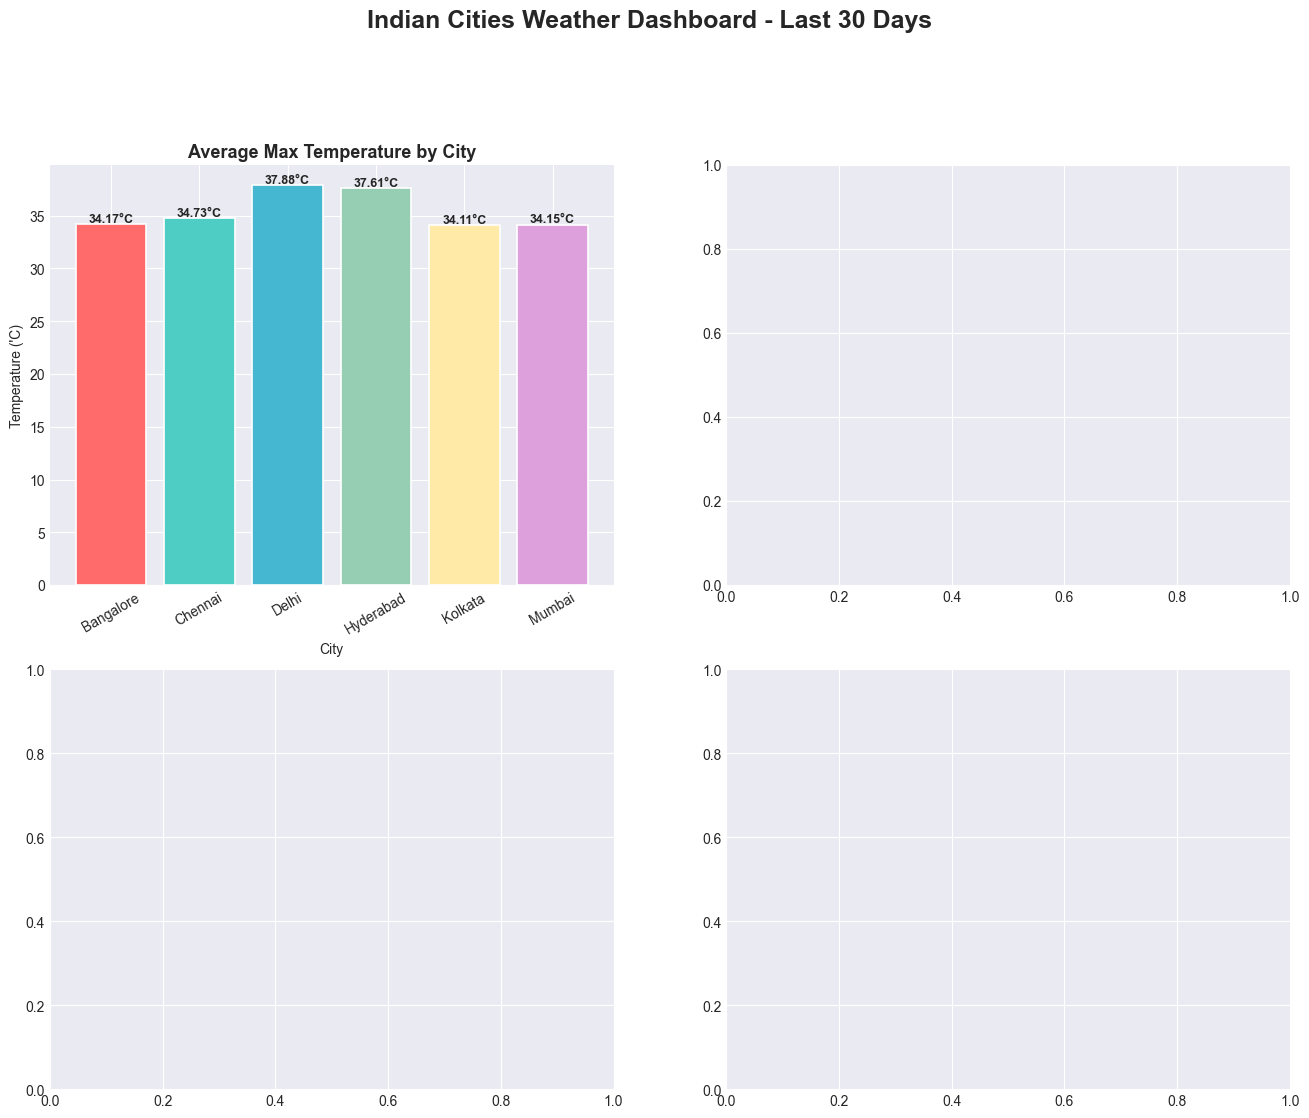

In [51]:
#Building the DashBoard
plt.style.use('seaborn-v0_8-darkgrid')

fig, axes = plt.subplots(2,2, figsize = (16,12)) # 4 Subplots

fig.suptitle("Indian Cities Weather Dashboard - Last 30 Days", fontsize = 18,
            fontweight = 'bold', y = 1.01)

#Bar Chart
colors_bar = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

axes[0,0].bar(city_summary["city"], city_summary["temp_max"],
             color = colors_bar, edgecolor = 'white', linewidth = 1.2)
axes[0,0].set_title("Average Max Temperature by City", fontsize = 13,
                   fontweight = 'bold')
axes[0,0].set_xlabel("City")
axes[0,0].set_ylabel("Temperature ('C)")
axes[0,0].tick_params(axis='x', labelrotation=30)

for i, v in enumerate(city_summary["temp_max"]):
    axes[0,0].text(i, v + 0.2, f'{v}°C', ha='center', fontsize=9, fontweight='bold')
                            #Only this lil part
                            #Visible


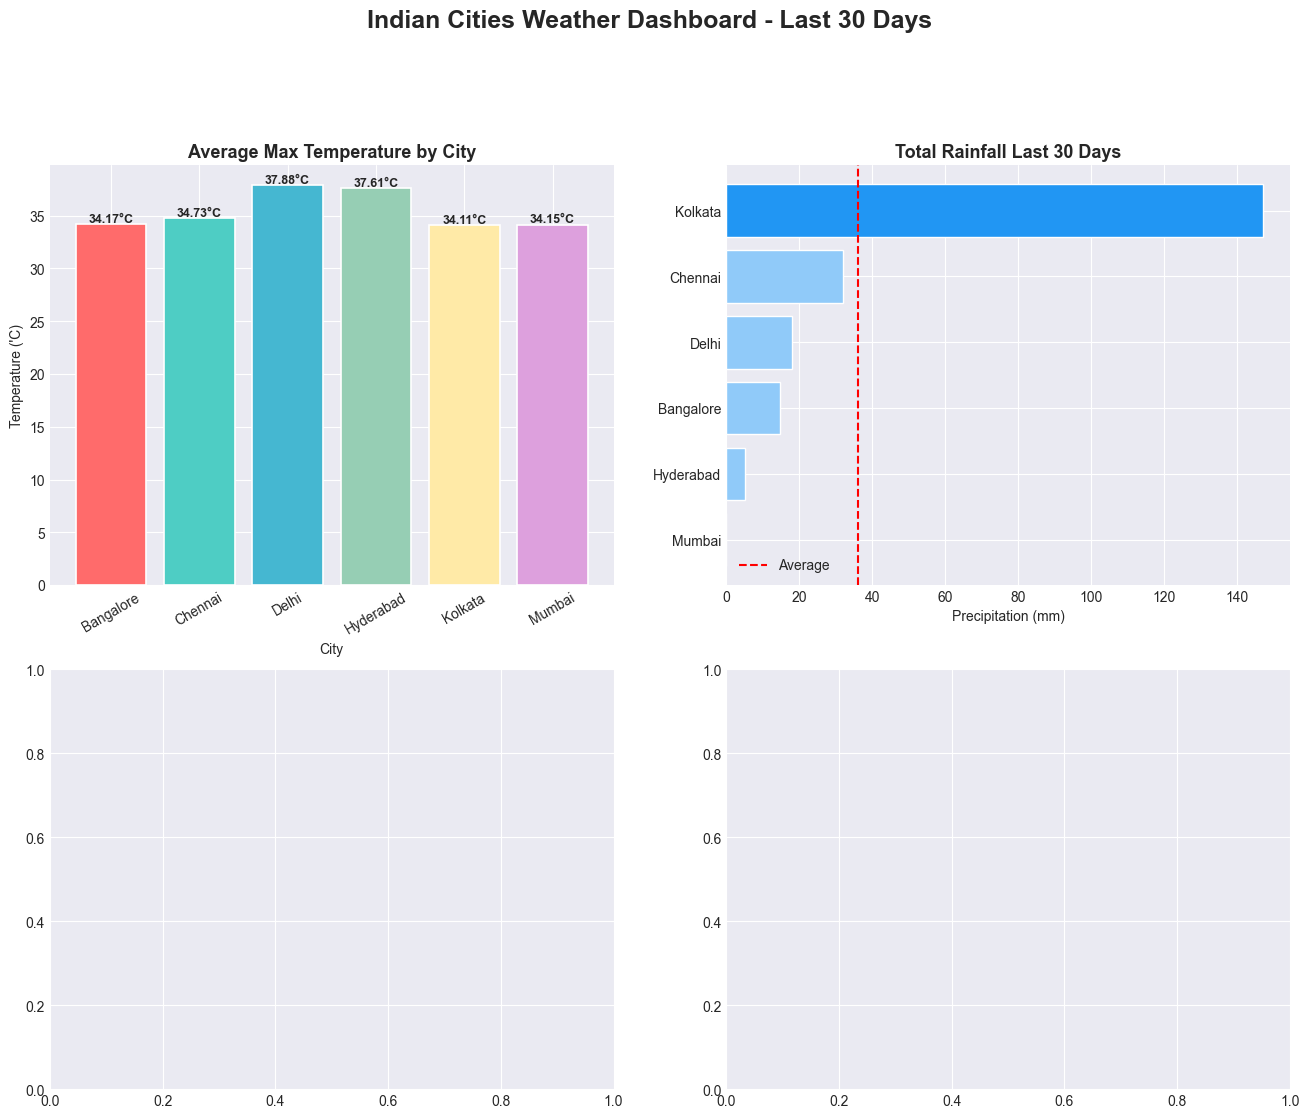

In [52]:
#Horizontal Bar

sorted_rain = city_summary.sort_values("precipitation", ascending=True)

bar_colors = ['#2196F3' if x > sorted_rain["precipitation"].mean()
              else '#90CAF9' for x in sorted_rain["precipitation"]]

axes[0,1].barh(sorted_rain["city"], sorted_rain["precipitation"]
              , color = bar_colors, edgecolor = 'white')
axes[0,1].axvline(sorted_rain["precipitation"].mean(),
                 color = 'red', linestyle = '--', linewidth = 1.5, 
                 label = 'Average')
axes[0,1].set_title('Total Rainfall Last 30 Days', fontsize = 13, fontweight = 
                   'bold')
axes[0,1].set_xlabel('Precipitation (mm)')
axes[0,1].legend()

fig

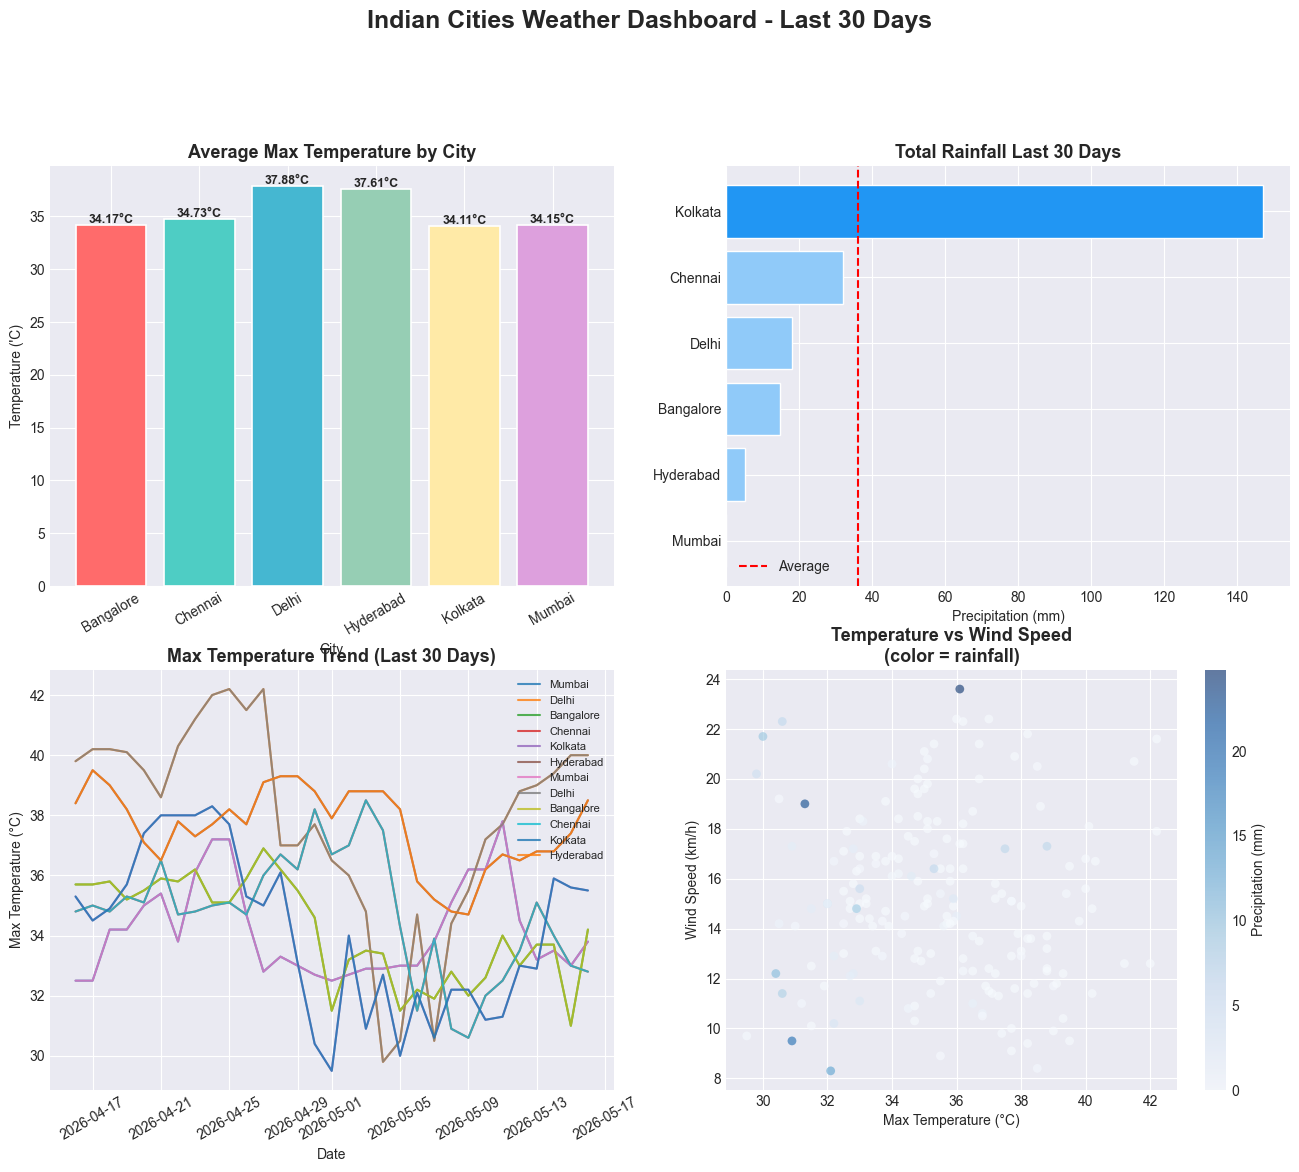

In [58]:
#Line Graph

for city in cities.keys():
    city_df = df[df['city'] == city].sort_values("date")
    axes[1,0].plot(city_df["date"], city_df["temp_max"],
                   label=city, linewidth=1.5, alpha=0.8)
    

axes[1,0].set_title('Max Temperature Trend (Last 30 Days)', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('Max Temperature (°C)')
axes[1,0].legend(fontsize=8, loc='upper right')
axes[1,0].tick_params(axis='x', rotation=30)

fig

C:\Users\Anay Duggal\AppData\Local\Temp\ipykernel_18612\49331993.py:7: UserWarning: Adding colorbar to a different Figure <Figure size 1600x1200 with 5 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, ax=axes[1,1], label='Precipitation (mm)')


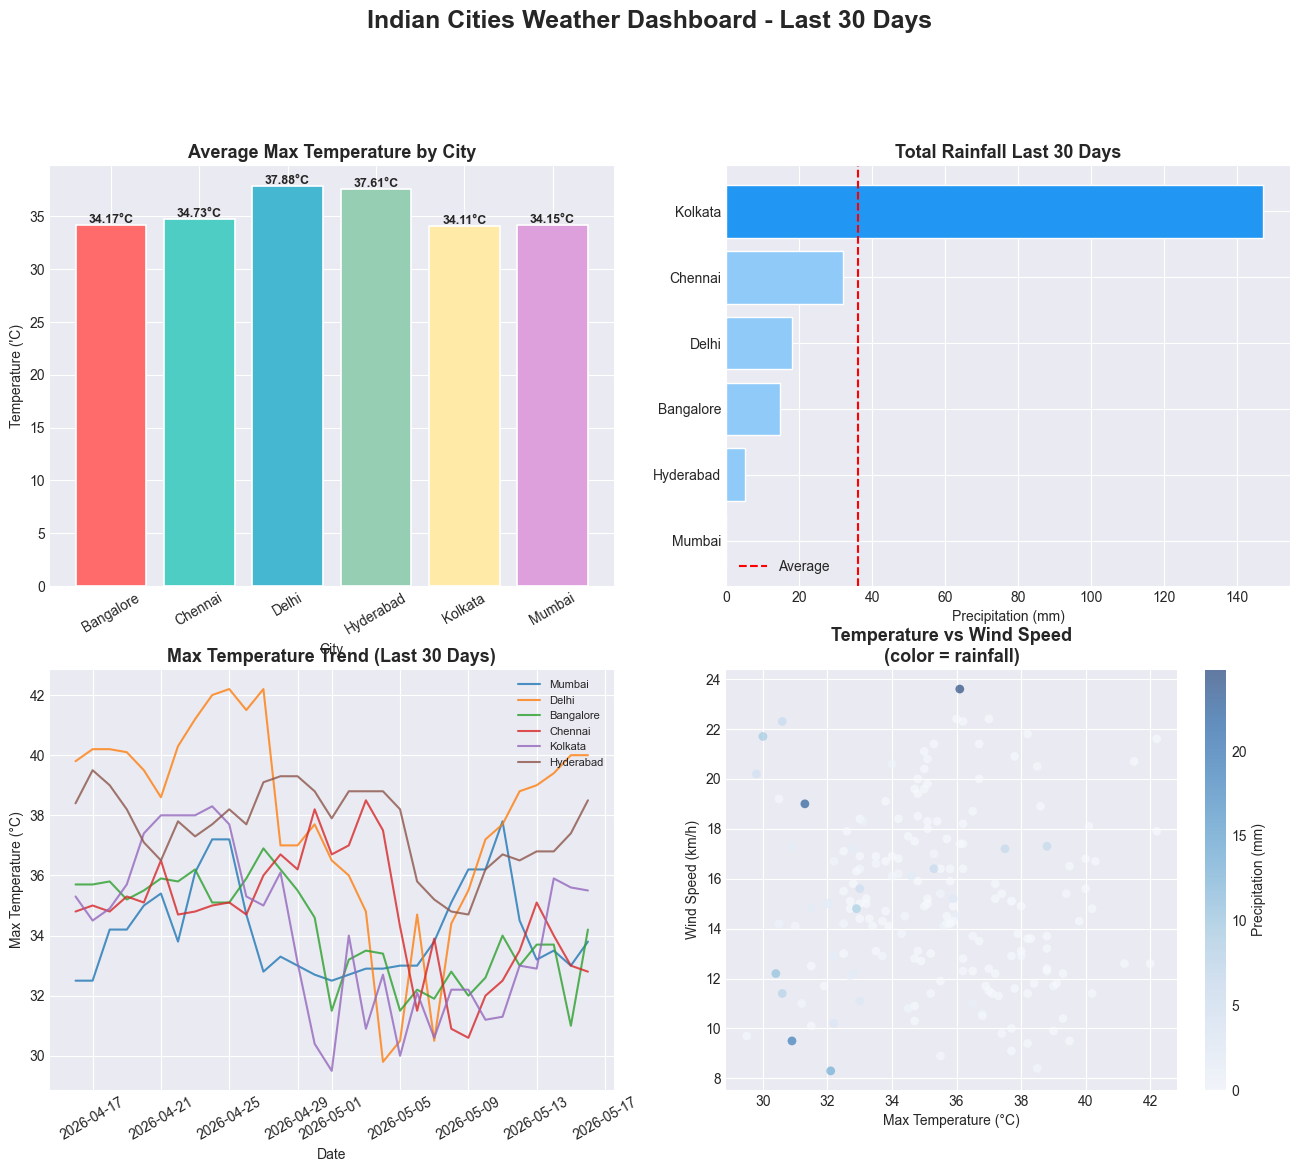

<Figure size 640x480 with 0 Axes>

In [55]:
#Scatter Plot

scatter = axes[1,1].scatter(df['temp_max'], df['windspeed'], 
                           c = df['precipitation'], cmap = 'Blues'
                           , s = 40, alpha = 0.6, edgecolors = 'none')

plt.colorbar(scatter, ax=axes[1,1], label='Precipitation (mm)')

axes[1,1].set_title('Temperature vs Wind Speed\n(color = rainfall)',
                     fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Max Temperature (°C)')
axes[1,1].set_ylabel('Wind Speed (km/h)')

fig

In [56]:
plt.tight_layout()
plt.savefig('weather_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved as weather_dashboard.png!")

<Figure size 640x480 with 0 Axes>

Dashboard saved as weather_dashboard.png!


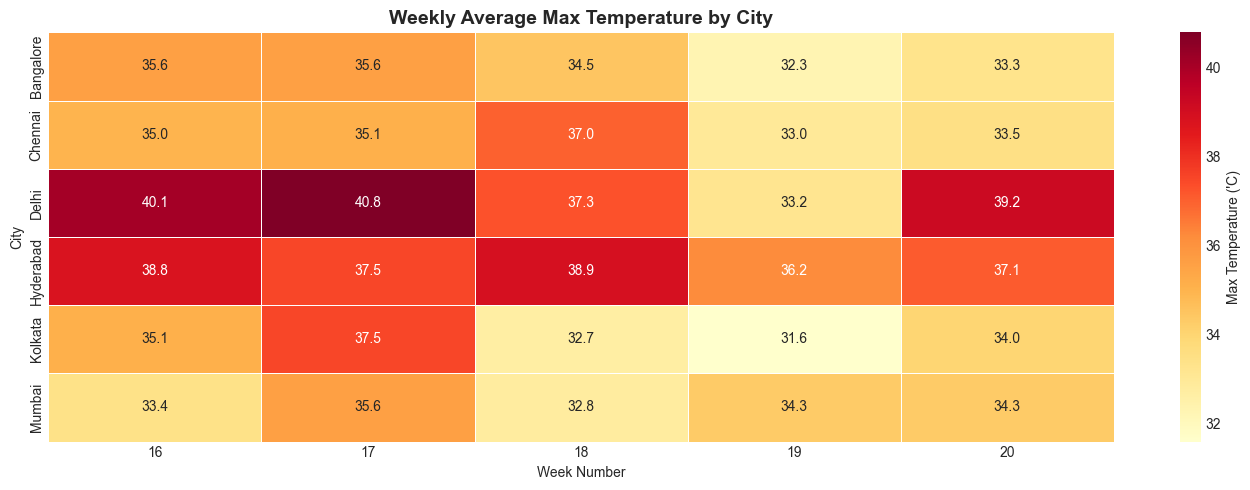

 Heatmap saved!


In [57]:
#Heatmap - Average Temperature per city per week

pivot = df.pivot_table(values = 'temp_max', index ='city', columns ='week'
                      , aggfunc = 'mean').round(1)

plt.figure(figsize = (14,5))

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Max Temperature (\'C)'})

plt.title('Weekly Average Max Temperature by City',
          fontsize=14, fontweight='bold')
plt.xlabel('Week Number')
plt.ylabel('City')
plt.tight_layout()
plt.savefig('temperature_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Heatmap saved!")